# Nonsense correlations from slow fluctuations — a walkthrough

Neurons fluctuate slowly. So does pupil diameter, and so does a task variable
that stays constant for a run of trials. Any two slow signals correlate, and
ordinary statistics — p-values, cross-validation — will call that correlation
real.

We simulate a population with **no** relationship to pupil and **no** encoding of
the task variable, watch several standard analyses declare otherwise, then work
through which controls catch the problem and which do not.


In [1]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold
from rastermap import Rastermap

logging.getLogger('rastermap').setLevel(logging.WARNING)   # quiet its progress messages

plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42


## 1. Simulate a session


In [2]:
SEED        = 7            # master random seed

N_NEURONS   = 100
N_BLOCKS    = 10           # task blocks in the session
BLOCK_LEN   = (30, 70)     # trials per block, drawn uniformly (inclusive)
TRIAL_DUR   = 1.0          # s, duration of one trial
DT          = 0.005        # s, resolution at which spikes are generated

FLUCT_TAU   = 25.0         # s, timescale of each neuron's slow rate fluctuation
PUPIL_TAU   = 20.0         # s, timescale of the pupil fluctuation
RATE_BASE   = (2.0, 9.0)   # spikes/s, each neuron's mean rate (drawn uniformly)
RATE_AMP    = 2.5          # spikes/s, sd of the slow fluctuation around that mean
TP_NOISE_SD = 0.0          # spikes/s, extra independent noise added to the rate at
                           # every timepoint, on top of the Poisson spiking noise


In [3]:
def slow_traces(rng, n_rows, n_pts, tau_pts):
    """n_rows independent smooth random traces of length n_pts: white noise
    low-pass filtered with a Gaussian of sd tau_pts, then z-scored so each row
    has mean 0 and sd 1. mode='wrap' makes each trace periodic, so a circular
    shift of a trace is still a valid sample from the same process."""
    z = gaussian_filter1d(rng.normal(0, 1, (n_rows, n_pts)), tau_pts, axis=1, mode='wrap')
    return z / z.std(axis=1, keepdims=True)


def make_blocks(rng, n_blocks=N_BLOCKS, lo=BLOCK_LEN[0], hi=BLOCK_LEN[1], n_trials=None):
    """A sequence of alternating +1 / -1 blocks: each block's length is drawn
    uniformly from lo..hi trials and the first block's sign is random. Returns
    (value on each trial, block id on each trial). Pass n_trials to get exactly
    that many trials -- which is how you draw a pseudosession later on."""
    sign = rng.choice([-1, 1])
    values, ids, i = [], [], 0
    while (len(values) < n_trials) if n_trials else (i < n_blocks):
        L = int(rng.integers(lo, hi + 1))
        values += [sign * (-1) ** i] * L      # this block's value, repeated
        ids    += [i] * L                     # this block's index, repeated
        i += 1
    values, ids = np.array(values), np.array(ids)
    return (values[:n_trials], ids[:n_trials]) if n_trials else (values, ids)


In [4]:
rng = np.random.default_rng(SEED)

# --- the task: a sequence of +/-1 blocks
block_values, block_ids = make_blocks(rng)
n_trials  = len(block_values)
per_trial = int(round(TRIAL_DUR / DT))        # timepoints in one trial
n_pts     = n_trials * per_trial              # timepoints in the session

# --- each neuron's firing rate: its own mean rate plus a slow fluctuation.
# Nothing here refers to the block variable or to the pupil: the neurons are
# generated completely independently of both.
rate_trial = (rng.uniform(*RATE_BASE, size=N_NEURONS)[:, None]
              + RATE_AMP * slow_traces(rng, N_NEURONS, n_trials, FLUCT_TAU / TRIAL_DUR))
rate_trial = rate_trial + rng.normal(0, TP_NOISE_SD, rate_trial.shape)   # 0 by default
rate_trial = np.clip(rate_trial, 0, None)     # a firing rate cannot be negative

# --- interpolate the per-trial rate onto the fine time grid, then draw spikes
# from an inhomogeneous Poisson process: independently in each 5 ms bin, the
# number of spikes is Poisson with mean rate*DT.
t_trial = (np.arange(n_trials) + 0.5) * TRIAL_DUR      # trial centres, s
t_pts   = np.arange(n_pts) * DT                        # fine time grid, s
rate    = np.array([np.interp(t_pts, t_trial, r) for r in rate_trial])   # spikes/s
spikes  = rng.poisson(rate * DT)                       # (neurons, timepoints)

# --- pupil diameter: the same kind of slow trace, also independent of everything
pupil = 0.5 + 0.15 * slow_traces(rng, 1, n_trials, PUPIL_TAU / TRIAL_DUR)[0]

print(f'{N_NEURONS} neurons, {n_trials} trials of {TRIAL_DUR:.0f} s '
      f'({n_trials*TRIAL_DUR/60:.1f} min), {N_BLOCKS} blocks')
print(f'firing rates span {rate.min():.1f} - {rate.max():.1f} spikes/s '
      f'(mean {rate.mean():.1f}); {spikes.sum():,} spikes total')


100 neurons, 511 trials of 1 s (8.5 min), 10 blocks
firing rates span 0.0 - 17.3 spikes/s (mean 5.3); 272,746 spikes total


## 2. Spike rasters


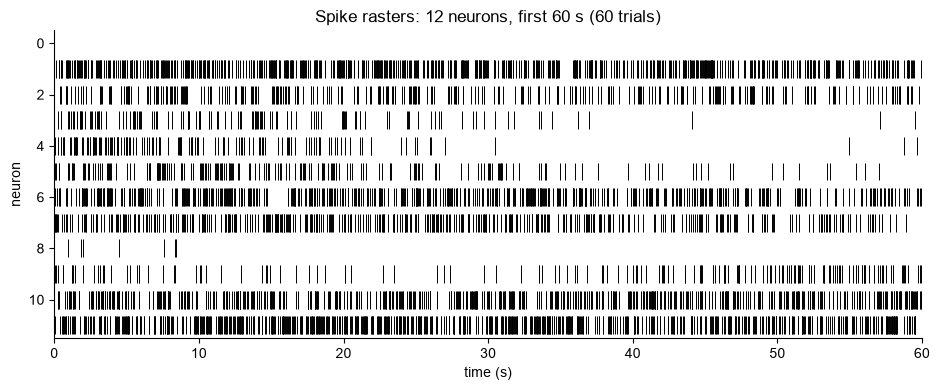

In [5]:
N_SHOW, T_SHOW = 12, 60      # neurons and seconds to display

fig, ax = plt.subplots(figsize=(9.5, 4))
# spike times of neuron i = the times of its non-empty bins, repeated by count
times = [np.repeat(t_pts, spikes[i]) for i in range(N_SHOW)]
ax.eventplot([t[t <= T_SHOW] for t in times], colors='k', linewidths=0.7,
             lineoffsets=np.arange(N_SHOW), linelengths=0.7)
ax.set_xlim(0, T_SHOW); ax.set_ylim(N_SHOW - 0.5, -0.5)
ax.set_yticks(np.arange(0, N_SHOW, 2))
ax.set_xlabel('time (s)'); ax.set_ylabel('neuron')
ax.set_title(f'Spike rasters: {N_SHOW} neurons, first {T_SHOW} s ({T_SHOW} trials)')
plt.tight_layout(); plt.show()


## 3. Spike counts binned by trial


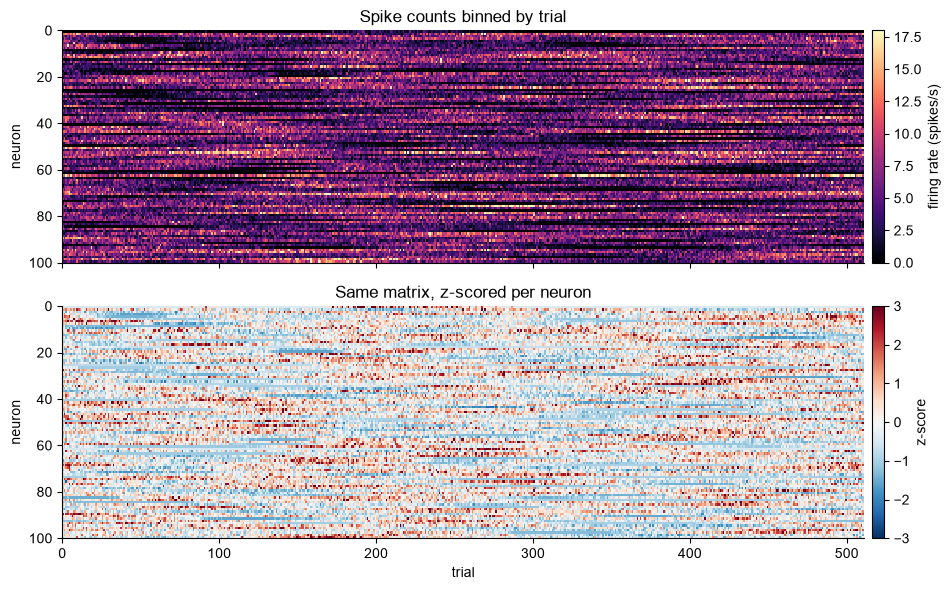

In [6]:
# one bin per trial: sum the fine-grained counts within each trial
counts = spikes.reshape(N_NEURONS, n_trials, per_trial).sum(axis=2)   # spikes per trial
fr     = counts / TRIAL_DUR                                          # spikes/s
# z-score each neuron across trials, so neurons with different mean rates are
# on the same colour scale
frz = (fr - fr.mean(axis=1, keepdims=True)) / fr.std(axis=1, keepdims=True)


def show_matrix(ax, M, cmap, vmin, vmax, title, cbar_label, ylabel='neuron'):
    """Draw a neurons x trials matrix. interpolation='nearest' is important:
    it stops matplotlib from blurring the image across neurons or across trials,
    which would invent structure that is not in the data."""
    im = ax.imshow(M, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest', extent=[0, M.shape[1], M.shape[0], 0])
    ax.set_ylabel(ylabel); ax.set_title(title)
    plt.colorbar(im, ax=ax, label=cbar_label, fraction=0.025, pad=0.01)
    return im


fig, axes = plt.subplots(2, 1, figsize=(9.5, 6), sharex=True)
show_matrix(axes[0], fr, 'magma', 0, np.percentile(fr, 99.5),
            'Spike counts binned by trial', 'firing rate (spikes/s)')
show_matrix(axes[1], frz, 'RdBu_r', -3, 3,
            'Same matrix, z-scored per neuron', 'z-score')
axes[1].set_xlabel('trial')
plt.tight_layout(); plt.show()


## 4. The same matrix, rows sorted by Rastermap


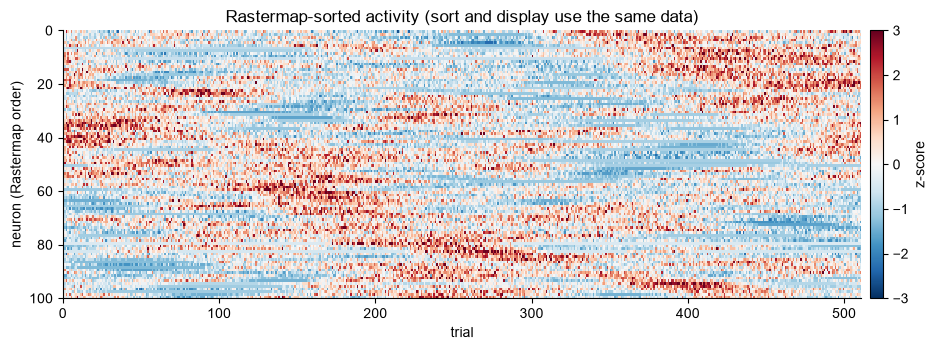

In [7]:
# Rastermap finds an ordering of the neurons that puts neurons with similar
# activity next to each other. It is fit on this same matrix -- there is no
# held-out data anywhere.
model = Rastermap(n_clusters=None, n_PCs=32, locality=0.5, time_lag_window=0).fit(frz)
isort = model.isort            # neuron indices in the order Rastermap chose

fig, ax = plt.subplots(figsize=(9.5, 3.6))
show_matrix(ax, frz[isort], 'RdBu_r', -3, 3,
            'Rastermap-sorted activity (sort and display use the same data)',
            'z-score', ylabel='neuron (Rastermap order)')
ax.set_xlabel('trial')
plt.tight_layout(); plt.show()


## 5. Test 1 — correlation with pupil diameter


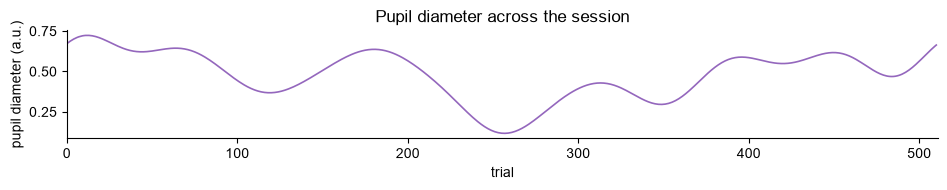

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 2))
ax.plot(pupil, color='tab:purple', lw=1.2)
ax.set_xlim(0, n_trials)
ax.set_xlabel('trial'); ax.set_ylabel('pupil diameter (a.u.)')
ax.set_title('Pupil diameter across the session')
plt.tight_layout(); plt.show()


In [9]:
def corr_rows(M, v):
    """Pearson correlation between every row of M and the vector v. Written as
    a dot product of z-scored variables (which is all a Pearson correlation is)
    so that we can run it thousands of times for the null distributions below."""
    Mz = (M - M.mean(axis=1, keepdims=True)) / M.std(axis=1, keepdims=True)
    vz = (v - v.mean()) / v.std()
    return (Mz @ vz) / v.size


def pval_from_r(r, n):
    """The standard parametric p-value for a Pearson r computed from n paired
    samples: a two-sided t-test on t = r*sqrt((n-2)/(1-r^2)) with n-2 degrees of
    freedom. This is exactly what scipy.stats.pearsonr returns."""
    t = r * np.sqrt((n - 2) / np.clip(1 - r ** 2, 1e-12, None))
    return 2 * stats.t.sf(np.abs(t), n - 2)


r_pupil = corr_rows(fr, pupil)
p_pupil = pval_from_r(r_pupil, n_trials)

# sanity check that these two helpers agree with scipy on one neuron
chk = stats.pearsonr(fr[0], pupil)
print(f'neuron 0   ours: r = {r_pupil[0]:+.4f}, p = {p_pupil[0]:.3g}')
print(f'neuron 0  scipy: r = {chk.statistic:+.4f}, p = {chk.pvalue:.3g}')


neuron 0   ours: r = -0.1813, p = 3.77e-05
neuron 0  scipy: r = -0.1813, p = 3.77e-05


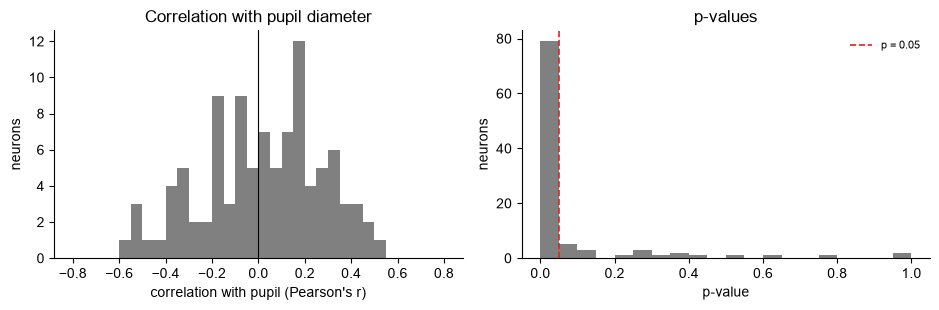

79 / 100 neurons significantly correlated with pupil at p < 0.05 (79%; 5% expected by chance)
median |r| = 0.181, largest |r| = 0.571


In [10]:
n_sig = np.sum(p_pupil < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].hist(r_pupil, bins=np.linspace(-0.8, 0.8, 33), color='0.5')
axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_xlabel("correlation with pupil (Pearson's r)"); axes[0].set_ylabel('neurons')
axes[0].set_title('Correlation with pupil diameter')
axes[1].hist(p_pupil, bins=np.linspace(0, 1, 21), color='0.5')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value'); axes[1].set_ylabel('neurons')
axes[1].set_title('p-values')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(f'{n_sig} / {N_NEURONS} neurons significantly correlated with pupil at p < 0.05 '
      f'({n_sig/N_NEURONS*100:.0f}%; 5% expected by chance)')
print(f'median |r| = {np.median(np.abs(r_pupil)):.3f}, '
      f'largest |r| = {np.max(np.abs(r_pupil)):.3f}')


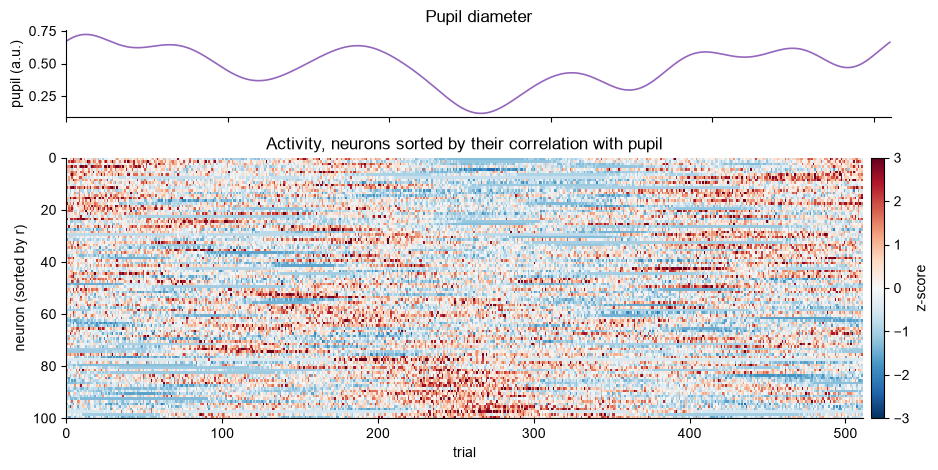

In [11]:
order_pupil = np.argsort(r_pupil)[::-1]        # most positively correlated first

fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.8), sharex=True,
                         gridspec_kw=dict(height_ratios=[1, 3]))
axes[0].plot(pupil, color='tab:purple', lw=1.2)
axes[0].set_ylabel('pupil (a.u.)'); axes[0].set_title('Pupil diameter')
show_matrix(axes[1], frz[order_pupil], 'RdBu_r', -3, 3,
            'Activity, neurons sorted by their correlation with pupil',
            'z-score', ylabel='neuron (sorted by r)')
axes[1].set_xlabel('trial'); axes[1].set_xlim(0, n_trials)
plt.tight_layout(); plt.show()


### Click a row to overlay that neuron on the pupil trace


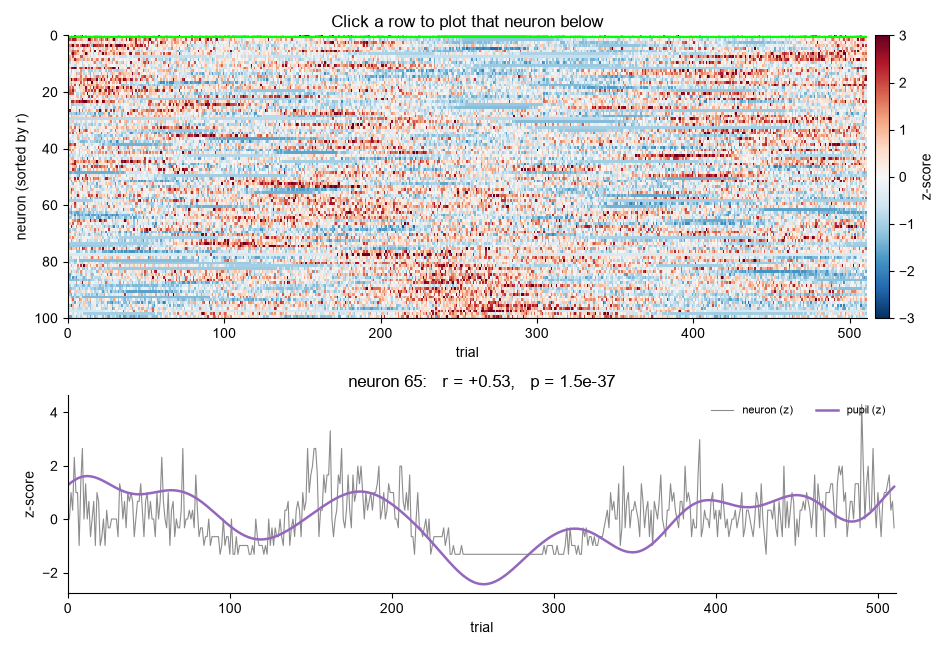

In [12]:
%matplotlib widget

pupil_z = (pupil - pupil.mean()) / pupil.std()
M_sorted = frz[order_pupil]

fig, (ax_im, ax_tr) = plt.subplots(2, 1, figsize=(9.5, 6.5),
                                   gridspec_kw=dict(height_ratios=[2, 1.4]))
fig.canvas.header_visible = False
show_matrix(ax_im, M_sorted, 'RdBu_r', -3, 3,
            'Click a row to plot that neuron below', 'z-score',
            ylabel='neuron (sorted by r)')
ax_im.set_xlabel('trial')
row_marker = ax_im.axhline(0.5, color='lime', lw=1.5)

line_neuron, = ax_tr.plot(M_sorted[0], color='0.55', lw=0.8, label='neuron (z)')
ax_tr.plot(pupil_z, color='tab:purple', lw=1.8, label='pupil (z)')
ax_tr.set_xlim(0, n_trials); ax_tr.set_xlabel('trial'); ax_tr.set_ylabel('z-score')
ax_tr.legend(frameon=False, fontsize=8, ncol=2, loc='upper right')


def show_row(row):
    """Draw the neuron in display row `row` of the sorted matrix."""
    i = order_pupil[row]
    line_neuron.set_ydata(frz[i])
    row_marker.set_ydata([row + 0.5, row + 0.5])
    ax_tr.set_title(f'neuron {i}:   r = {r_pupil[i]:+.2f},   p = {p_pupil[i]:.1e}')
    ax_tr.relim(); ax_tr.autoscale_view(scalex=False)
    fig.canvas.draw_idle()


def on_click(event):
    if event.inaxes is ax_im and event.ydata is not None:
        show_row(int(np.clip(event.ydata, 0, N_NEURONS - 1)))


fig.canvas.mpl_connect('button_press_event', on_click)
show_row(0)
plt.tight_layout()


In [13]:
%matplotlib inline


## 6. A control that fails: shuffle each neuron's timecourse


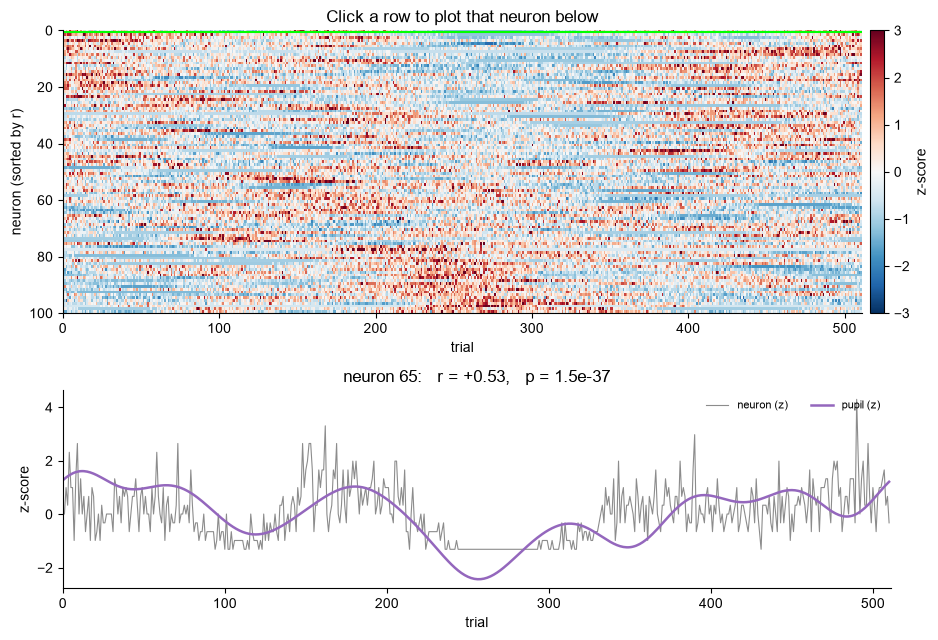

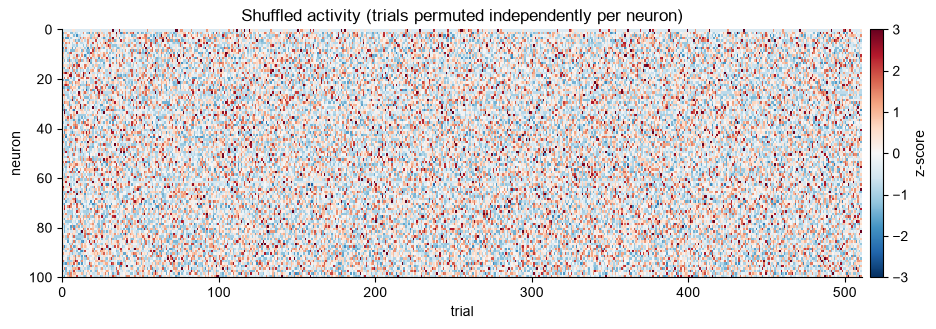

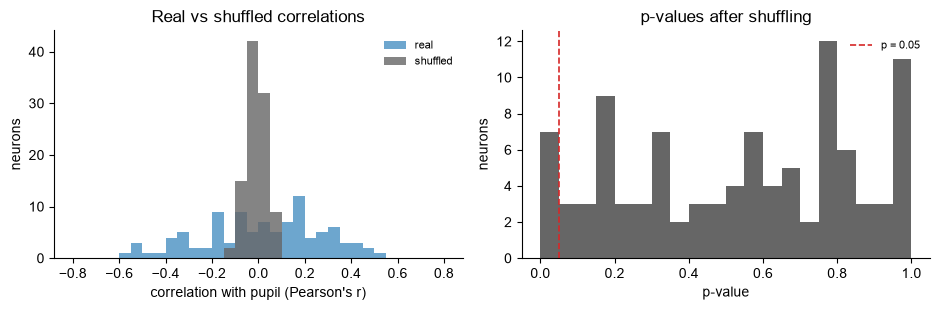

real     :  79 / 100 neurons significant (p < 0.05)
shuffled :   7 / 100 neurons significant (p < 0.05)


In [14]:
# independently permute the trials of each neuron: this keeps every neuron's
# distribution of firing rates but destroys its slow temporal structure
fr_shuffled = np.array([rng.permutation(row) for row in fr])
frz_shuffled = ((fr_shuffled - fr_shuffled.mean(axis=1, keepdims=True))
                / fr_shuffled.std(axis=1, keepdims=True))

r_shuffled = corr_rows(fr_shuffled, pupil)         # vs the real pupil trace
p_shuffled = pval_from_r(r_shuffled, n_trials)
n_sig_shuffled = np.sum(p_shuffled < 0.05)

fig, ax = plt.subplots(figsize=(9.5, 3.4))
show_matrix(ax, frz_shuffled, 'RdBu_r', -3, 3,
            'Shuffled activity (trials permuted independently per neuron)', 'z-score')
ax.set_xlabel('trial')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].hist(r_pupil, bins=np.linspace(-0.8, 0.8, 33), color='tab:blue',
             alpha=0.65, label='real')
axes[0].hist(r_shuffled, bins=np.linspace(-0.8, 0.8, 33), color='0.4',
             alpha=0.8, label='shuffled')
axes[0].set_xlabel("correlation with pupil (Pearson's r)"); axes[0].set_ylabel('neurons')
axes[0].set_title('Real vs shuffled correlations')
axes[0].legend(frameon=False, fontsize=8)
axes[1].hist(p_shuffled, bins=np.linspace(0, 1, 21), color='0.4')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value'); axes[1].set_ylabel('neurons')
axes[1].set_title('p-values after shuffling')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(f'real     : {n_sig:3d} / {N_NEURONS} neurons significant (p < 0.05)')
print(f'shuffled : {n_sig_shuffled:3d} / {N_NEURONS} neurons significant (p < 0.05)')


The shuffle sits at chance, so the real result looks like a real effect. But the
shuffle destroyed the slow structure that produced it — so it was never a test
of the claim.


## 7. Two controls that work


### 7a. Circularly shift each neuron


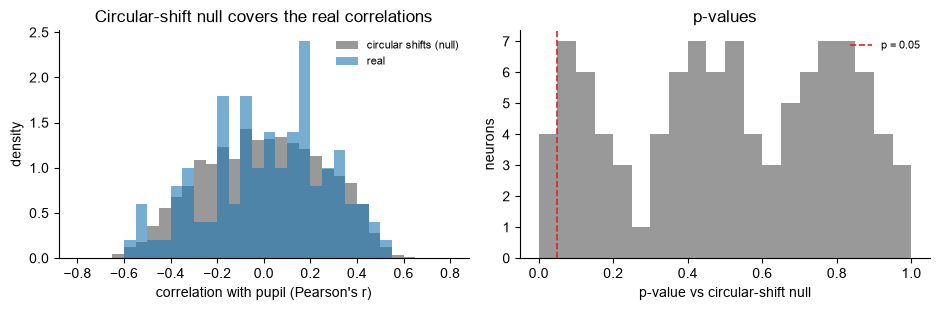

parametric p < 0.05        :  79 / 100 neurons
vs circular-shift null     :   4 / 100 neurons


In [15]:
N_SHIFT = 200
shift_amounts = rng.integers(1, n_trials, N_SHIFT)

# A circular shift slides a neuron's whole timecourse in time, keeping its slow
# structure intact but breaking any true alignment with the pupil trace.
r_circ = np.array([corr_rows(np.roll(fr, s, axis=1), pupil) for s in shift_amounts])
# per-neuron p-value: how often does a shifted version reach |r| as large as the
# unshifted one?
p_circ = (np.sum(np.abs(r_circ) >= np.abs(r_pupil), axis=0) + 1) / (N_SHIFT + 1)
n_sig_circ = np.sum(p_circ < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].hist(r_circ.ravel(), bins=np.linspace(-0.8, 0.8, 33), density=True,
             color='0.6', label='circular shifts (null)')
axes[0].hist(r_pupil, bins=np.linspace(-0.8, 0.8, 33), density=True,
             color='tab:blue', alpha=0.6, label='real')
axes[0].set_xlabel("correlation with pupil (Pearson's r)"); axes[0].set_ylabel('density')
axes[0].set_title('Circular-shift null covers the real correlations')
axes[0].legend(frameon=False, fontsize=8)
axes[1].hist(p_circ, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs circular-shift null'); axes[1].set_ylabel('neurons')
axes[1].set_title('p-values')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(f'parametric p < 0.05        : {n_sig:3d} / {N_NEURONS} neurons')
print(f'vs circular-shift null     : {n_sig_circ:3d} / {N_NEURONS} neurons')


### 7b. Correlate with a different session's pupil trace


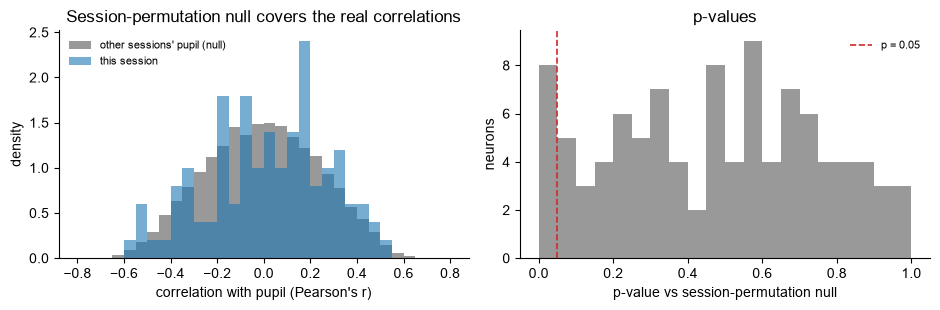

parametric p < 0.05        :  79 / 100 neurons
vs session-permutation null:   8 / 100 neurons


In [16]:
N_SESSIONS = 200
# pupil traces from "other sessions": drawn from the same generative process,
# so they have the same slow structure but no relation to these neurons
other_pupil = 0.5 + 0.15 * slow_traces(rng, N_SESSIONS, n_trials, PUPIL_TAU / TRIAL_DUR)

r_other = np.array([corr_rows(fr, p) for p in other_pupil])
p_other = (np.sum(np.abs(r_other) >= np.abs(r_pupil), axis=0) + 1) / (N_SESSIONS + 1)
n_sig_other = np.sum(p_other < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].hist(r_other.ravel(), bins=np.linspace(-0.8, 0.8, 33), density=True,
             color='0.6', label="other sessions' pupil (null)")
axes[0].hist(r_pupil, bins=np.linspace(-0.8, 0.8, 33), density=True,
             color='tab:blue', alpha=0.6, label='this session')
axes[0].set_xlabel("correlation with pupil (Pearson's r)"); axes[0].set_ylabel('density')
axes[0].set_title('Session-permutation null covers the real correlations')
axes[0].legend(frameon=False, fontsize=8)
axes[1].hist(p_other, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs session-permutation null'); axes[1].set_ylabel('neurons')
axes[1].set_title('p-values')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(f'parametric p < 0.05        : {n_sig:3d} / {N_NEURONS} neurons')
print(f'vs session-permutation null: {n_sig_other:3d} / {N_NEURONS} neurons')


## 8. Test 2 — decoding the block variable


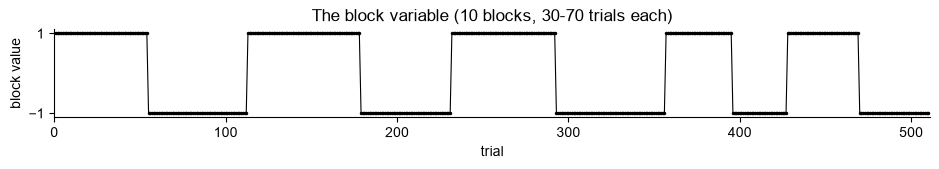

In [17]:
fig, ax = plt.subplots(figsize=(9.5, 1.8))
ax.plot(block_values, '.-', ms=3, lw=0.8, color='k')
ax.set_xlim(0, n_trials); ax.set_yticks([-1, 1])
ax.set_xlabel('trial'); ax.set_ylabel('block value')
ax.set_title(f'The block variable ({N_BLOCKS} blocks, {BLOCK_LEN[0]}-{BLOCK_LEN[1]} trials each)')
plt.tight_layout(); plt.show()


In [18]:
X = fr.T                  # sklearn wants (samples, features) = (trials, neurons)
y = block_values


def trialwise_cv(X, y, folds=10, seed=0):
    """Ordinary k-fold cross-validation: trials are shuffled and split into
    folds, each fold is predicted by a decoder trained on the other folds."""
    kf = KFold(folds, shuffle=True, random_state=seed)
    return np.mean([LinearDiscriminantAnalysis().fit(X[tr], y[tr]).score(X[te], y[te])
                    for tr, te in kf.split(X)])


acc = trialwise_cv(X, y)
print(f'Trial-wise cross-validated accuracy: {acc*100:.1f}%   (chance = 50%)')


Trial-wise cross-validated accuracy: 81.4%   (chance = 50%)


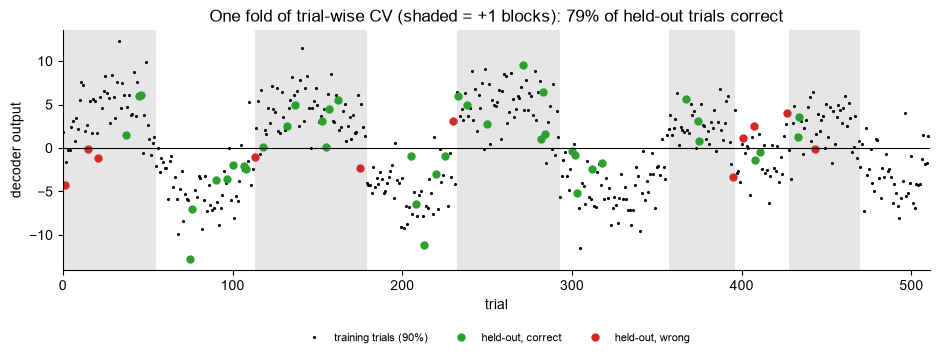

In [19]:
def plot_fold(ax, X, y, train, test, title):
    """Train a decoder on `train` and plot its continuous output for every
    trial: training trials in black, held-out trials green if the sign of the
    output matches the true block and red if it does not."""
    model = LinearDiscriminantAnalysis().fit(X[train], y[train])
    out = model.decision_function(X)              # continuous decoder output
    ok = np.sign(out[test]) == y[test]
    for b in np.unique(block_ids):               # shade the +1 blocks
        idx = np.where(block_ids == b)[0]
        if block_values[idx[0]] > 0:
            ax.axvspan(idx[0], idx[-1] + 1, color='0.9', lw=0, zorder=0)
    ax.plot(train, out[train], '.', color='k', ms=2.5,
            label=f'training trials ({len(train)/len(y)*100:.0f}%)')
    ax.plot(test[ok], out[test][ok], 'o', color='tab:green', ms=5, label='held-out, correct')
    ax.plot(test[~ok], out[test][~ok], 'o', color='tab:red', ms=5, label='held-out, wrong')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlim(0, n_trials); ax.set_xlabel('trial'); ax.set_ylabel('decoder output')
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8, ncol=3, loc='upper center',
              bbox_to_anchor=(0.5, -0.22))
    return np.mean(ok)


train, test = next(iter(KFold(10, shuffle=True, random_state=0).split(X)))
fig, ax = plt.subplots(figsize=(9.5, 3.8))
fold_acc = plot_fold(ax, X, y, train, test, 'One fold of trial-wise CV (shaded = +1 blocks)')
ax.set_title(f'One fold of trial-wise CV (shaded = +1 blocks): '
             f'{fold_acc*100:.0f}% of held-out trials correct')
plt.tight_layout(); plt.show()


## 9. The same failing control: shuffle each neuron's timecourse


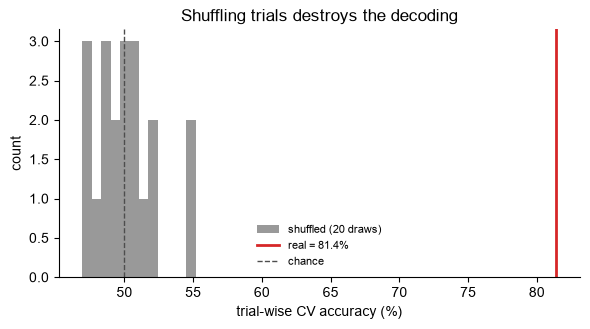

real     : 81.4%
shuffled : 50.0% +/- 2.2% (max 55.2%)


In [20]:
N_SHUFFLE = 20
acc_shuffled = np.array([
    trialwise_cv(np.array([rng.permutation(row) for row in fr]).T, y)
    for _ in range(N_SHUFFLE)])

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(acc_shuffled * 100, bins=12, color='0.6', label=f'shuffled ({N_SHUFFLE} draws)')
ax.axvline(acc * 100, color='tab:red', lw=2, label=f'real = {acc*100:.1f}%')
ax.axvline(50, color='0.3', ls='--', lw=1, label='chance')
ax.set_xlabel('trial-wise CV accuracy (%)'); ax.set_ylabel('count')
ax.set_title('Shuffling trials destroys the decoding')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(f'real     : {acc*100:.1f}%')
print(f'shuffled : {acc_shuffled.mean()*100:.1f}% +/- {acc_shuffled.std()*100:.1f}% '
      f'(max {acc_shuffled.max()*100:.1f}%)')


## 10. Two controls that work


### 10a. Pseudosessions


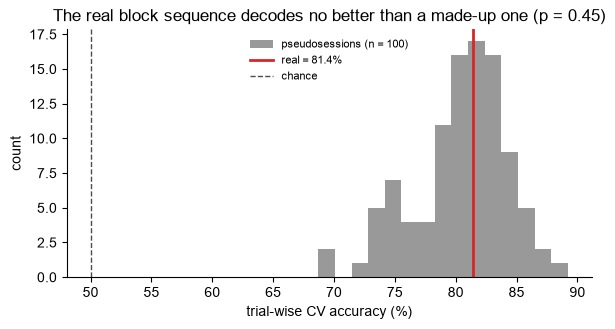

pseudosessions: 80.4% +/- 3.9%
real          : 81.4%    p = 0.45


In [21]:
N_PSEUDO = 100
# A pseudosession is a block sequence drawn from the same generative process as
# the real one -- same number of blocks, same length distribution -- but it is
# not the sequence this session actually had. Decode each one the same way.
acc_pseudo = np.array([
    trialwise_cv(X, make_blocks(rng, n_trials=n_trials)[0], folds=5)
    for _ in range(N_PSEUDO)])
acc_real5 = trialwise_cv(X, y, folds=5)
p_pseudo = (np.sum(acc_pseudo >= acc_real5) + 1) / (N_PSEUDO + 1)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(acc_pseudo * 100, bins=15, color='0.6', label=f'pseudosessions (n = {N_PSEUDO})')
ax.axvline(acc_real5 * 100, color='tab:red', lw=2, label=f'real = {acc_real5*100:.1f}%')
ax.axvline(50, color='0.3', ls='--', lw=1, label='chance')
ax.set_xlabel('trial-wise CV accuracy (%)'); ax.set_ylabel('count')
ax.set_title(f'The real block sequence decodes no better than a made-up one (p = {p_pseudo:.2f})')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(f'pseudosessions: {acc_pseudo.mean()*100:.1f}% +/- {acc_pseudo.std()*100:.1f}%')
print(f'real          : {acc_real5*100:.1f}%    p = {p_pseudo:.2f}')


### 10b. Leave one block out


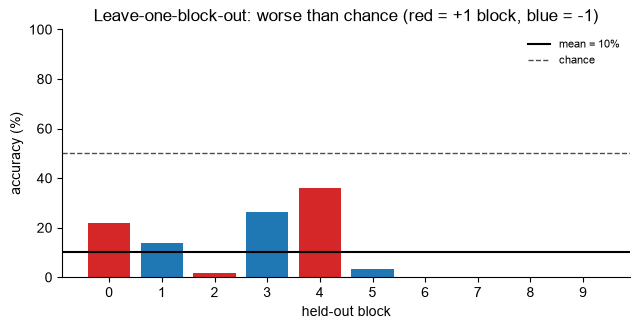

trial-wise CV       : 81.4%
leave-one-block-out : 10.3%


In [22]:
# Hold out every trial of one block at a time, so no trial from the held-out
# block -- and none of its slow fluctuation state -- is in the training set.
blocks = np.unique(block_ids)
acc_blockout = np.array([
    LinearDiscriminantAnalysis().fit(X[block_ids != b], y[block_ids != b])
    .score(X[block_ids == b], y[block_ids == b]) for b in blocks])

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(blocks, acc_blockout * 100,
       color=['tab:red' if block_values[block_ids == b][0] > 0 else 'tab:blue'
              for b in blocks])
ax.axhline(np.mean(acc_blockout) * 100, color='k',
           label=f'mean = {np.mean(acc_blockout)*100:.0f}%')
ax.axhline(50, color='0.3', ls='--', lw=1, label='chance')
ax.set_xticks(blocks); ax.set_ylim(0, 100)
ax.set_xlabel('held-out block'); ax.set_ylabel('accuracy (%)')
ax.set_title('Leave-one-block-out: worse than chance (red = +1 block, blue = -1)')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print(f'trial-wise CV       : {acc*100:.1f}%')
print(f'leave-one-block-out : {np.mean(acc_blockout)*100:.1f}%')


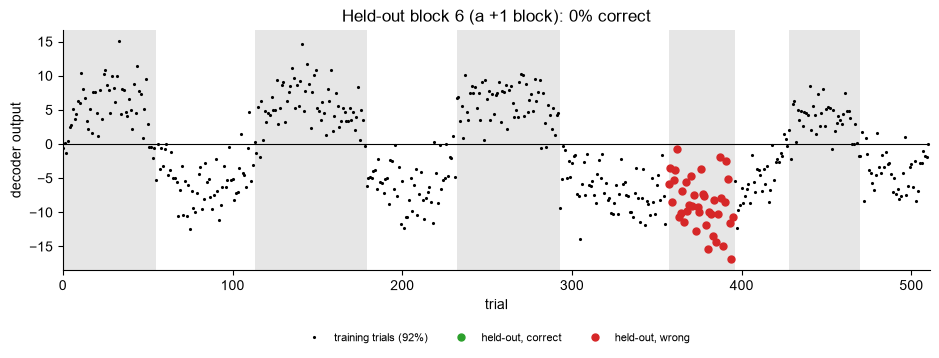

In [23]:
# One held-out block in the style of the fold plot above: every trial of this
# block is in the test set, and the decoder mostly calls it the wrong sign --
# the neighbouring blocks, which the decoder did train on, had the opposite value.
b = int(blocks[np.argmin(acc_blockout)])
test_b = np.where(block_ids == b)[0]
train_b = np.where(block_ids != b)[0]

fig, ax = plt.subplots(figsize=(9.5, 3.8))
plot_fold(ax, X, y, train_b, test_b,
          f'Held-out block {b} (a {block_values[test_b[0]]:+d} block): '
          f'{acc_blockout[b]*100:.0f}% correct')
plt.tight_layout(); plt.show()
